#### 1.订单表的长度，shape，columns
#### 2.统计菜名的平均价格(amounts)
#### 3.什么菜最受欢迎
#### 4.哪个订单ID点菜最多
# ...

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']='SimHei'
%matplotlib inline

# 1.加载数据
data1 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail1')
data2 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail2')
data3 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail3')
# 2.数据预处理（NA等梳理），分析数据
data = pd.concat([data1,data2,data3],axis=0) #按照行并行进行拼接
# data.head(5)
data.dropna(axis=1,inplace=True) #按照列删除Na列,并且修改源数据
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10037 entries, 0 to 3610
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   detail_id         10037 non-null  int64         
 1   order_id          10037 non-null  int64         
 2   dishes_id         10037 non-null  int64         
 3   dishes_name       10037 non-null  object        
 4   itemis_add        10037 non-null  int64         
 5   counts            10037 non-null  int64         
 6   amounts           10037 non-null  int64         
 7   place_order_time  10037 non-null  datetime64[ns]
 8   add_inprice       10037 non-null  int64         
 9   picture_file      10037 non-null  object        
 10  emp_id            10037 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 941.0+ KB


In [67]:
#统计卖出菜品的平均价格
round(data['amounts'].mean(),2) #方法一：pandas自带函数
round(np.mean(data['amounts']),2) #方法二:numpy函数处理

np.float64(44.82)

0 323
1 269
2 239
3 216
4 189
5 188
6 187
7 186
8 178
9 173


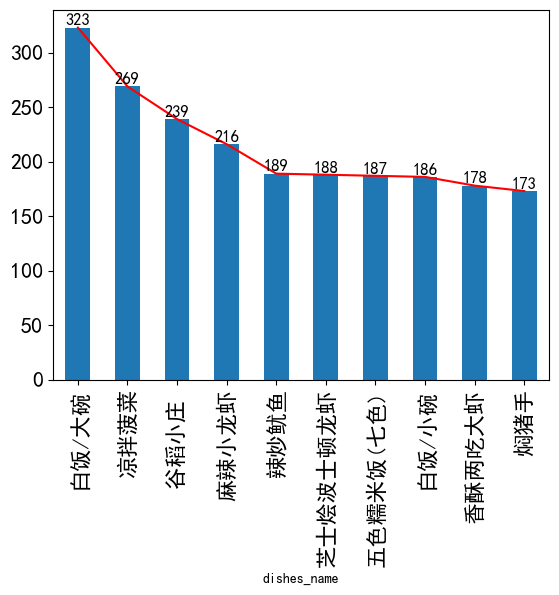

In [68]:
# 频数统计，什么菜最受欢迎（对菜名进行频数统计，去最大前十名）
dishes_count = data['dishes_name'].value_counts()[:10]
# 3.数据可视化matplotlib
dishes_count.plot(kind='line',color=['r'])
dishes_count.plot(kind='bar',fontsize=16)
for x,y in enumerate(dishes_count):
    print(x,y)
    plt.text(x,y+2,y,ha='center',fontsize=12)

Text(0, 0.5, '点菜种类')

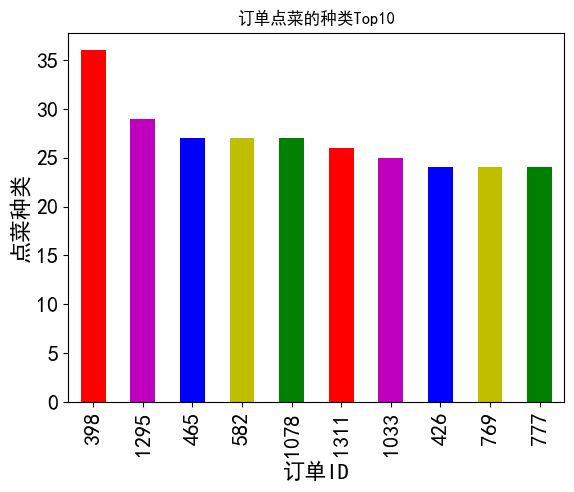

In [69]:
# 订单点菜数的种类最多（1，1，1   1，2，3）
data_group = data['order_id'].value_counts()[:10]
data_group.plot(kind='bar',fontsize=16,color=['r','m','b','y','g'])
plt.title('订单点菜的种类Top10')
plt.xlabel('订单ID',fontsize=16)
plt.ylabel('点菜种类',fontsize=16)
# 8月份餐厅订单点菜种类前10名，平均点菜25个菜品


Text(0.5, 1.0, '订单ID点菜数量Top10')

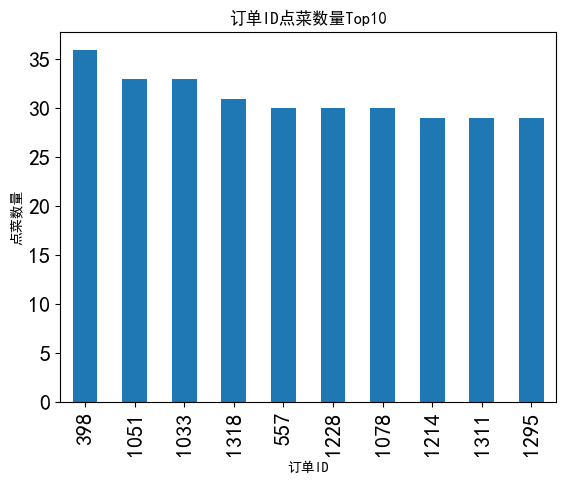

In [70]:
# 订单ID点菜数量Top10（分组order_id,counts求和,排序,前十）
data['total_amounts'] = data['counts']*data['amounts']
dataGroup = data[['order_id','counts','amounts','total_amounts']].groupby(by='order_id')
Group_sum = dataGroup.sum()
sort_counts = Group_sum.sort_values(by='counts',ascending=False)
sort_counts['counts'][:10].plot(kind='bar',fontsize=16)
plt.xlabel('订单ID')
plt.ylabel('点菜数量')
plt.title('订单ID点菜数量Top10')

Text(0.5, 1.0, '消费金额前10')

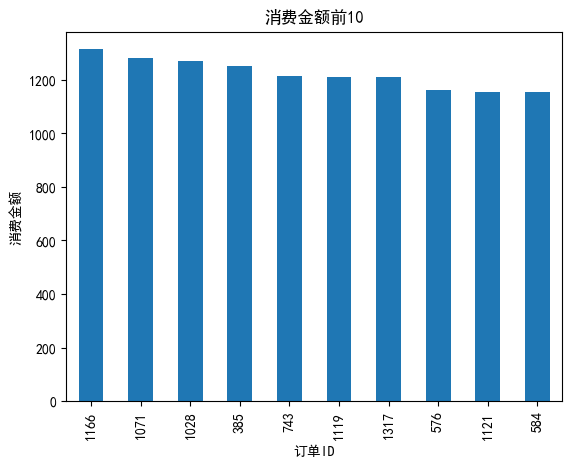

In [71]:
#哪个订单ID吃的前最多（排序）
sort_total_amounts = Group_sum.sort_values(by='total_amounts',ascending=False)
sort_total_amounts['total_amounts'][:10].plot(kind='bar')
plt.xlabel('订单ID')
plt.ylabel('消费金额')
plt.title('消费金额前10')

Text(0.5, 1.0, '订单消费单价前10')

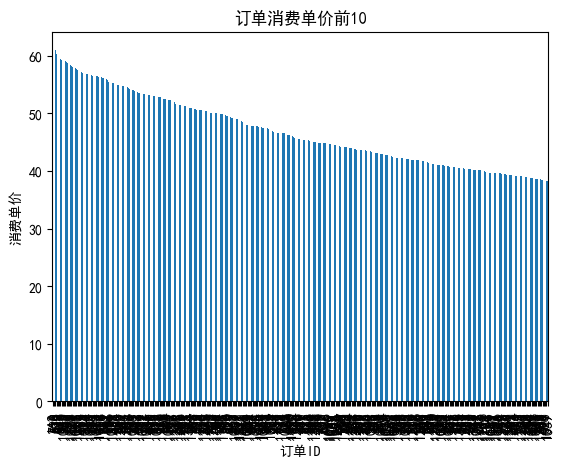

In [72]:
#哪个订单ID平均消费最贵
Group_sum['average'] = Group_sum['total_amounts']/Group_sum['counts']
sort_average = Group_sum.sort_values(by='average',ascending=False)
sort_average['average'][100:500].plot(kind='bar')
plt.xlabel('订单ID')
plt.ylabel('消费单价')
plt.title('订单消费单价前10')

Text(0.5, 1.0, '点菜数量与小时的关系图')

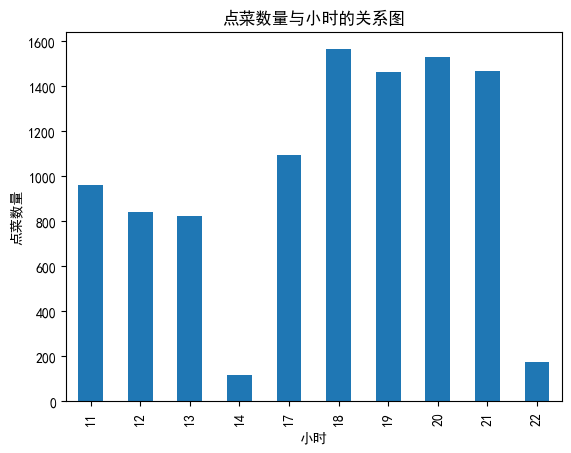

In [80]:
#一天当中什么时间段，点菜量比较集中（hour）
data['hourcount'] = 1
data['time'] =pd.to_datetime(data['place_order_time'])
data['hour'] = data['time'].map(lambda x:x.hour)
data.groupby(by='hour').count()['hourcount']
gp_by_hour = data.groupby(by='hour').count()['hourcount']
gp_by_hour.plot(kind='bar')
plt.xlabel('小时')
plt.ylabel('点菜数量')
plt.title('点菜数量与小时的关系图')

Text(0.5, 1.0, '点菜数量与小时的关系图')

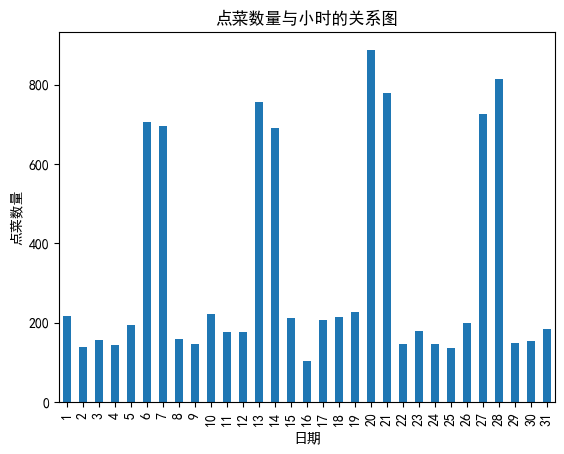

In [81]:
#那一天订餐数量最多
data['datacount'] = 1
data['day'] = data['time'].map(lambda x:x.day)
gp_by_day = data.groupby(by='day').count()['datacount']
gp_by_day.plot(kind='bar')
plt.xlabel('日期')
plt.ylabel('点菜数量')
plt.title('点菜数量与小时的关系图')

Text(0.5, 1.0, '点菜数量与星期的关系图')

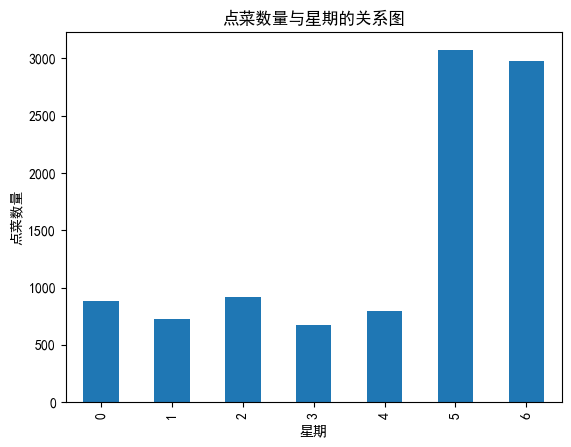

In [83]:
data['weekcount'] = 1
data['weekday'] = data['time'].map(lambda x:x.weekday())
gp_by_weekday = data.groupby(by='weekday').count()['weekcount']
gp_by_weekday.plot(kind='bar')
plt.xlabel('星期')
plt.ylabel('点菜数量')
plt.title('点菜数量与星期的关系图')

In [ ]:
# 不同维度进行数据分析：
# 针对订单order_id：
# 1.什么菜最受欢迎
# 2.点菜的种类
# 3.点菜的数量
# 4.消费金额最多
# 5.平均消费
# 针对不同日期进行分析:
# 1.点菜量比较集中的时间
# 2.哪一天订餐量最大
# 3.星期几就餐人数最多
# 技术点:
# 1.拼接数据:pd.concat
# 2.分组进行统计（分组求和）
# 3.排序,切片Top10
# 4.绘制柱状图走势和高度